In [31]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# 2. Load dataset
df = pd.read_csv("Land Price in Hanoi 2025 new.csv", encoding='utf-8')

# 3. Clean column names
df.columns = df.columns.str.strip().str.lower()

# 4. Fix price columns
price_cols = ['vt1','vt2','vt3','vt4']
for col in price_cols:
    df[col] = df[col].astype(str).str.replace(",", ".").str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 5. Drop rows with missing price data
df.dropna(subset=price_cols, inplace=True)

# 6. Confirm dataset
print("Cleaned shape:", df.shape)
df.head()

Cleaned shape: (168, 6)


,district,ward,vt1,vt2,vt3,vt4
0,BA ĐÌNH,Cống Vị,149.88,80.30,62.43,55.27
1,BA ĐÌNH,Giảng Võ,186.89,96.43,74.31,65.38
2,BA ĐÌNH,Kim Mã,196.90,101.09,77.80,68.39
3,BA ĐÌNH,Liễu Giai,198.63,102.18,78.68,69.19
4,BA ĐÌNH,Nguyễn Trung Trực,193.82,99.76,76.83,67.57


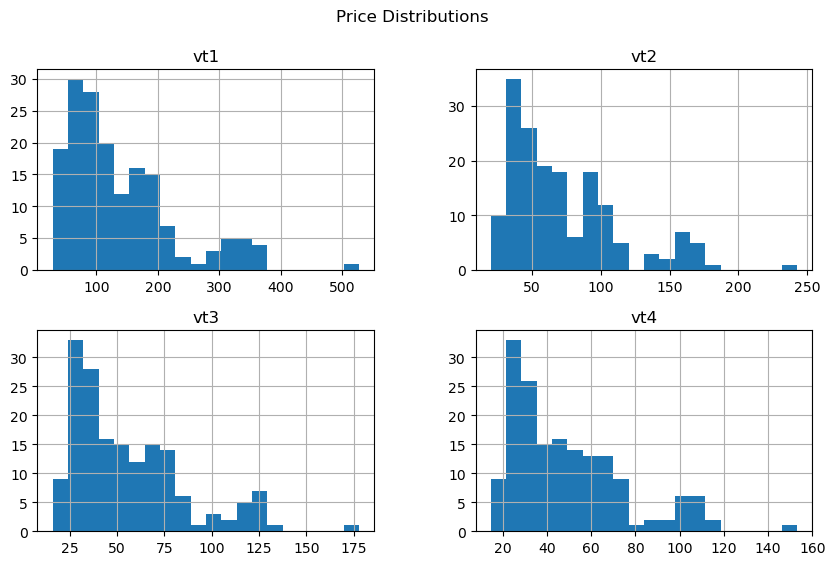

In [38]:
# Histograms
df[price_cols].hist(bins=20, figsize=(10,6))
plt.suptitle("Price Distributions")
plt.show()

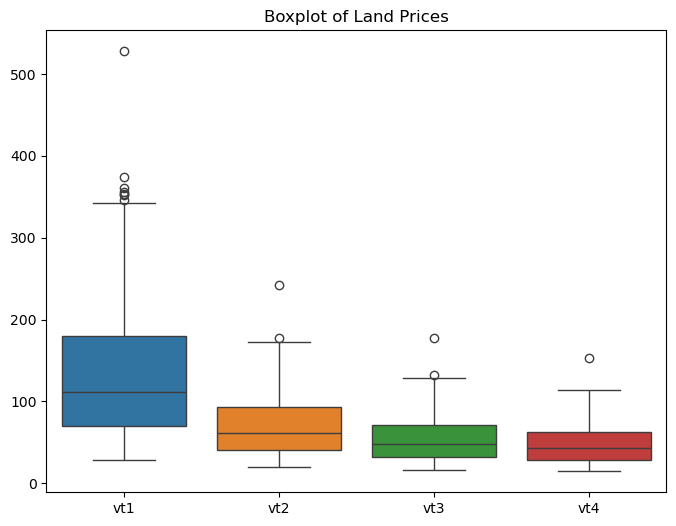

In [39]:
#Boxplots
plt.figure(figsize=(8,6))
sns.boxplot(data=df[price_cols])
plt.title("Boxplot of Land Prices")
plt.show()

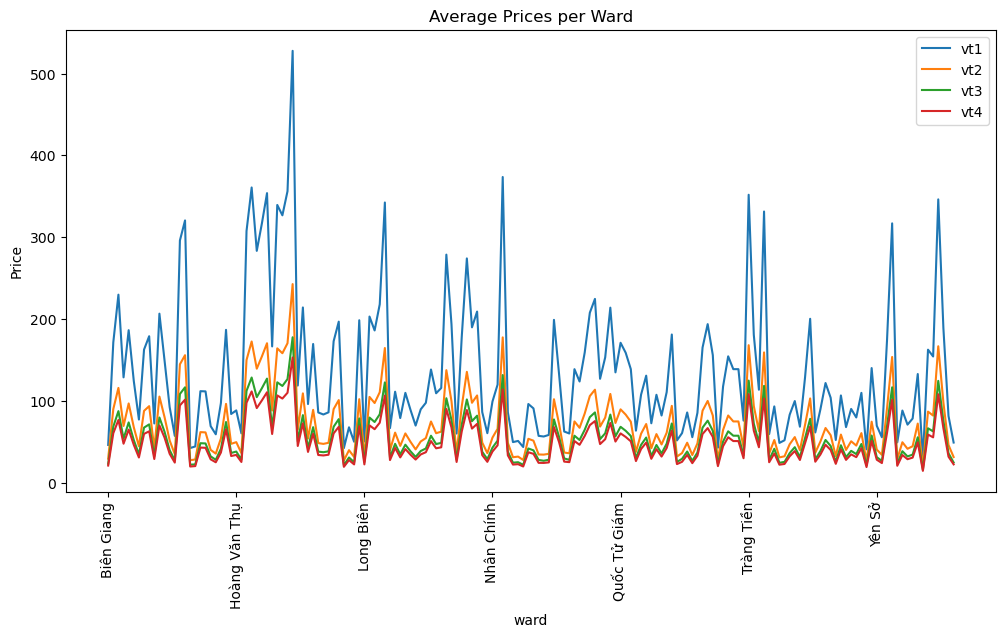

In [34]:
#Line Chart (Ward Averages)
ward_avg = df.groupby('ward')[price_cols].mean()
ward_avg.plot(kind='line', figsize=(12,6))
plt.title("Average Prices per Ward")
plt.ylabel("Price")
plt.xticks(rotation=90)
plt.show()

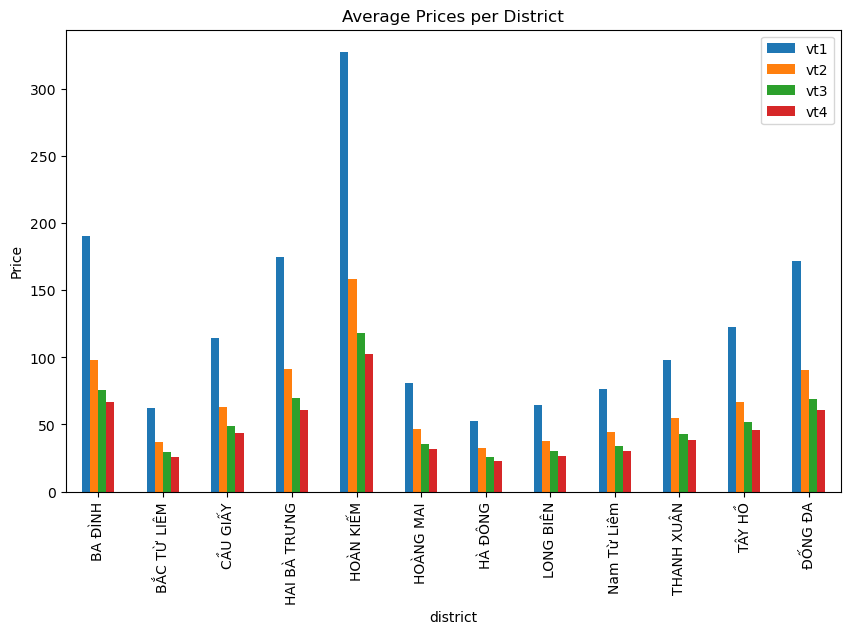

In [40]:
# Bar Chart (District Averages)
district_avg = df.groupby('district')[price_cols].mean()
district_avg.plot(kind='bar', figsize=(10,6))
plt.title("Average Prices per District")
plt.ylabel("Price")
plt.show()

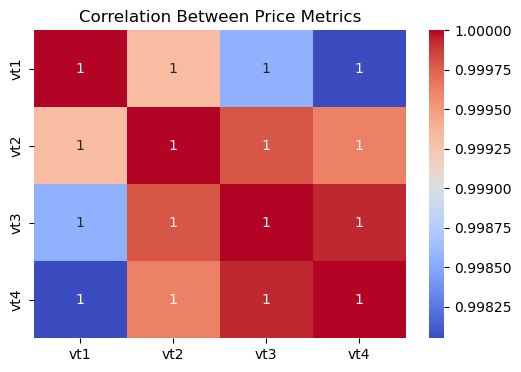

In [41]:
# Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df[price_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Price Metrics")
plt.show()

In [ ]:
A. DATA AUDIT
-Shape: 168 rows, 6 columns
-Column meaning: Contains districts, wards and prices of the lands.
-Missing values summary: No missing value detected
-Data quality issue: Usage of commas instead of dots for decimals.

B.CLEANING
-Handling missing values: There were no missing values, the dataset seemed to have been cleaned up before.
-Data types: Fixed them from object to float64

C.EDA
-Target distribution:1.Histogram - To show price distribution spread in each metric.
                     2.Line chart -To show trends across wards.
-Meaningful relationships:
1. Price Correlation Across VT1–VT4
- What it shows: Whether different valuation tiers (VT1–VT4) move together.
- Why it matters: High correlation suggests consistent pricing logic across metrics — useful for modeling or predicting missing values.
2. Ward-Level Price Trends
- What it shows: How average prices vary across wards.
- Why it matters: Reveals spatial inequality or hotspots for investment.
3. District-Level Price Distribution
- What it shows: How pricing differs between districts.
- Why it matters: Helps compare urban vs. suburban areas, or identify undervalued regions.

D. WRITTEN CONCLUSIONS:
INSIGHTS
-No missing values
-No duplicates
LIMITATIONS
-Dataset is descriptive only; it cannot explain *why* prices change (e.g., policy, infrastructure, demand).

ONE QUESTION TH DATASET CANNOT ANSWER
-Why are land prices increasing or decreasing in a specific ward?
